<a href="https://colab.research.google.com/github/sayed02-debug/big_five_personality/blob/main/BigFive_Multiple_Models_Comparison_Prototype_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install -q scikit-learn pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import hamming_loss, f1_score, classification_report


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from google.colab import drive

print("Prepare")

Prepare


In [27]:
drive.mount('/content/drive')


DATA_PATH = "/content/drive/MyDrive/behaviour_dataset/personality_dataset_10000.csv"

df = pd.read_csv(DATA_PATH)


print("Shape →", df.shape)
print("\n3 row:")
display(df.head(3))


print("\nTrait's positive ratio:")
print(df[['openness','conscientiousness','extraversion','agreeableness','neuroticism']].mean())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape → (10000, 6)

3 row:


,cv_text,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,I am sensitive to criticism and tend to worry ...,1,0,1,0,0
1,I am sensitive to criticism and tend to worry ...,0,0,1,1,0
2,I prefer to work alone and tend to avoid socia...,0,1,0,1,0



Trait's positive ratio:
openness             0.4937
conscientiousness    0.5071
extraversion         0.5047
agreeableness        0.5040
neuroticism          0.4977
dtype: float64


In [29]:
trait_cols = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']


df['clean_text'] = (
    df['cv_text']
    .astype(str)
    .str.lower()
    .str.replace(r'[^a-z\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

X = df['clean_text']
y = df[trait_cols]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y.sum(axis=1)
)


vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

joblib.dump(vectorizer, '/content/drive/MyDrive/Thesis_2026/Results/tfidf_vectorizer.pkl')

print("TF-IDF: ")
print("Train shape →", X_train_tfidf.shape)
print("Test shape  →", X_test_tfidf.shape)

TF-IDF: 
Train shape → (8000, 64)
Test shape  → (2000, 64)


→ Logistic Regression Continue...
   Macro F1: 0.5261 | Hamming: 0.4990 | Time: 0.2s

→ Naive Bayes Continue...
   Macro F1: 0.5050 | Hamming: 0.4991 | Time: 0.0s

→ Linear SVM Continue...
   Macro F1: 0.5261 | Hamming: 0.4990 | Time: 0.1s

→ Decision Tree Continue...
   Macro F1: 0.5261 | Hamming: 0.4990 | Time: 0.1s

→ Random Forest Continue...
   Macro F1: 0.5261 | Hamming: 0.4990 | Time: 3.0s

→ KNN Continue...
   Macro F1: 0.5349 | Hamming: 0.4958 | Time: 0.0s



,Hamming Loss,Macro F1,Micro F1,Train Time (s)
KNN,0.4958,0.5349,0.5378,0.02
Logistic Regression,0.4990,0.5261,0.5301,0.16
Decision Tree,0.4990,0.5261,0.5301,0.05
Linear SVM,0.4990,0.5261,0.5301,0.07
Random Forest,0.4990,0.5261,0.5301,3.04
Naive Bayes,0.4991,0.5050,0.5104,0.03


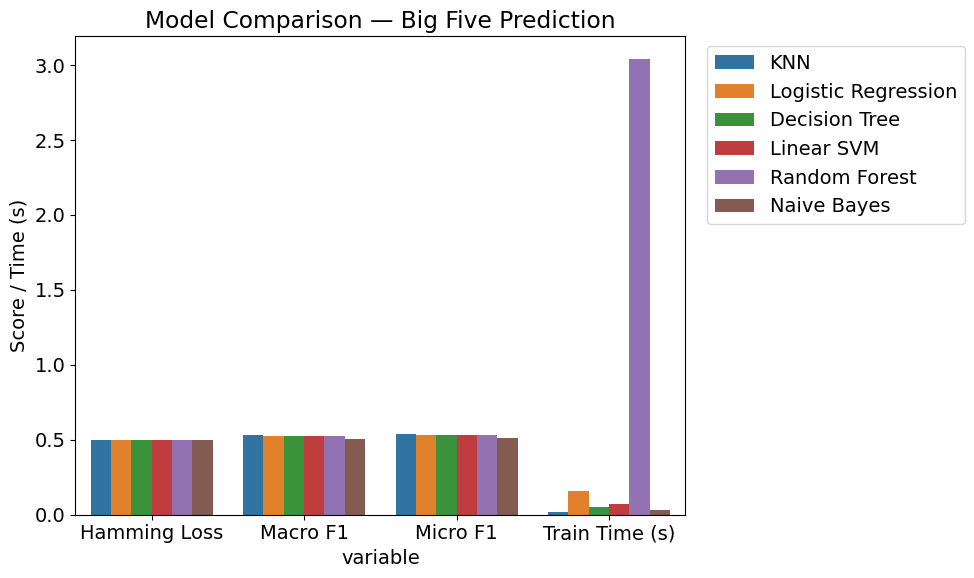

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(max_iter=3000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, max_depth=12, n_jobs=-1, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=25, n_jobs=-1)
}

results = {}


for name, clf in models.items():
    print(f"→ {name} Continue...")
    multi_clf = MultiOutputClassifier(clf)

    start = time.time()
    multi_clf.fit(X_train_tfidf, y_train)
    train_time = time.time() - start

    y_pred = multi_clf.predict(X_test_tfidf)

    ham = hamming_loss(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)

    results[name] = {
        "Hamming Loss": round(ham, 4),
        "Macro F1": round(f1_macro, 4),
        "Micro F1": round(f1_micro, 4),
        "Train Time (s)": round(train_time, 2)
    }


    joblib.dump(multi_clf, f'/content/drive/MyDrive/Thesis_2026/Results/{name.replace(" ", "_")}_model.pkl')

    print(f"   Macro F1: {f1_macro:.4f} | Hamming: {ham:.4f} | Time: {train_time:.1f}s\n")


df_results = pd.DataFrame(results).T.sort_values("Macro F1", ascending=False)
display(df_results)

df_results.to_csv('/content/drive/MyDrive/Thesis_2026/Results/model_comparison.csv')


plt.figure(figsize=(10, 6))
sns.barplot(data=df_results.reset_index().melt(id_vars='index'),
            x='variable', y='value', hue='index')
plt.title("Model Comparison — Big Five Prediction")
plt.ylabel("Score / Time (s)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
best_model_name = df_results.index[0]
print(f"Best Model: {best_model_name}")

best_model = joblib.load(f'/content/drive/MyDrive/Thesis_2026/Results/{best_model_name.replace(" ", "_")}_model.pkl')

y_pred_best = best_model.predict(X_test_tfidf)

print("\nClassification Report (per trait):\n")
print(classification_report(y_test, y_pred_best, target_names=trait_cols))

Best Model: KNN

Classification Report (per trait):

                   precision    recall  f1-score   support

         openness       0.50      0.62      0.55       962
conscientiousness       0.50      0.61      0.55      1010
     extraversion       0.52      0.63      0.57      1031
    agreeableness       0.52      0.41      0.46      1029
      neuroticism       0.49      0.61      0.54       984

        micro avg       0.51      0.57      0.54      5016
        macro avg       0.51      0.58      0.53      5016
     weighted avg       0.51      0.57      0.53      5016
      samples avg       0.41      0.56      0.45      5016



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
# Probability
best_model_name = df_results.index[0]
model = joblib.load(f'/content/drive/MyDrive/Thesis_2026/Results/{best_model_name.replace(" ", "_")}_model.pkl')

# Logistic / LinearSVC / NB → predict_proba
sample_texts = [
    "I love meeting new people and trying adventurous things.",
    "I prefer quiet evenings with a book and hate crowds."
]

for text in sample_texts:
    cleaned = text.lower().replace(r'[^a-z\s]', '').strip()
    vec = vectorizer.transform([cleaned])

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(vec)
        print(f"\nText: {text}")
        for i, trait in enumerate(trait_cols):
            print(f"{trait:15} → {probs[i][0][1]:.3f}")
    else:
        print("This model has no predict_proba।")


Text: I love meeting new people and trying adventurous things.
openness        → 0.440
conscientiousness → 0.520
extraversion    → 0.560
agreeableness   → 0.240
neuroticism     → 0.520

Text: I prefer quiet evenings with a book and hate crowds.
openness        → 0.520
conscientiousness → 0.560
extraversion    → 0.600
agreeableness   → 0.440
neuroticism     → 0.560


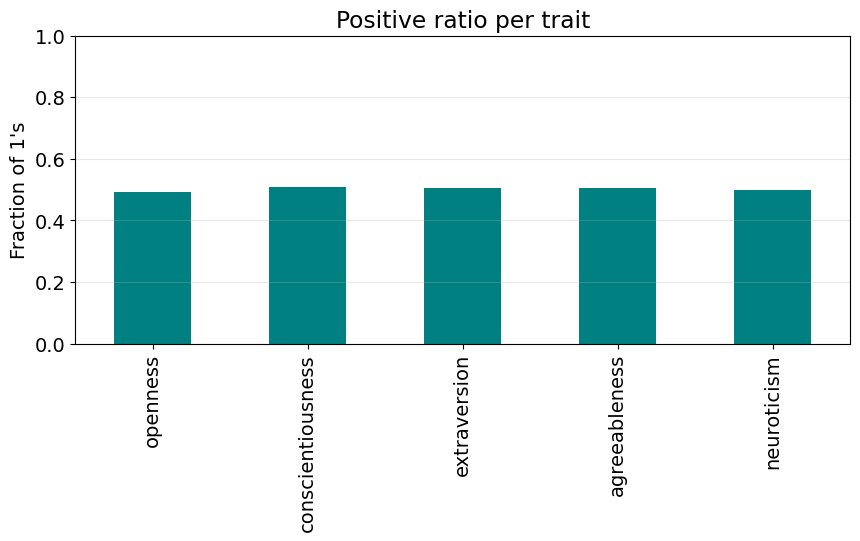

In [33]:
# Imbalance check
plt.figure(figsize=(10, 4))
y.mean().plot(kind='bar', color='teal')
plt.title("Positive ratio per trait")
plt.ylabel("Fraction of 1's")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [49]:
%%writefile app.py
# ============================================================
#       Big Five Personality Predictor - Streamlit App
#
# ============================================================

import streamlit as st
import joblib
from pathlib import Path

st.set_page_config(
    page_title="Big Five Predictor",
    page_icon="🧠",
    layout="centered",
    initial_sidebar_state="collapsed"
)

# ─── Header ────────────────────────────────────────────────
st.markdown(
    """
    <h2 style='text-align: center; color: #1a73e8; margin-bottom: 8px;'>
        🧠 Big Five Personality Predictor
    </h2>
    <p style='text-align: center; color: #555; margin-top: 0;'>
        Describe yourself in a few sentences — discover your Big Five traits
    </p>
    """,
    unsafe_allow_html=True
)

# ─── Input Area ────────────────────────────────────────────
with st.container():
    st.markdown("<div style='max-width: 720px; margin: 0 auto; padding: 0 16px;'>", unsafe_allow_html=True)

    user_text = st.text_area(
        "Tell us about yourself (or paste from CV / bio)",
        height=160,
        placeholder="Example: I am quite organized, love planning things in advance, but sometimes I worry too much about small details...",
        key="user_input"
    )

    model_choice = st.selectbox(
        "Choose a model",
        [
            "Logistic_Regression",
            "Linear_SVM",
            "SVM",
            "Naive_Bayes",
            "Random_Forest",
            "Decision_Tree",
            "KNN"
        ],
        index=0,
        help="Logistic Regression and Linear SVM usually give the best balance of accuracy and speed in this project."
    )

    predict_btn = st.button("Analyze My Personality →", type="primary", use_container_width=True)

    st.markdown("</div>", unsafe_allow_html=True)

# ─── Model name mapping (matches exactly what exists in your Drive) ──
MODEL_FILES = {
    "Logistic_Regression": "Logistic_Regression_model.pkl",
    "Linear_SVM":          "Linear_SVM_model.pkl",
    "SVM":                 "SVM_model.pkl",
    "Naive_Bayes":         "Naive_Bayes_model.pkl",
    "Random_Forest":       "Random_Forest_model.pkl",
    "Decision_Tree":       "Decision_Tree_model.pkl",
    "KNN":                 "KNN_model.pkl"
}

# ─── Prediction Logic ──────────────────────────────────────
if predict_btn:
    if not user_text.strip():
        st.warning("Please write something about yourself first 😊")
    else:
        with st.spinner("Analyzing your text..."):
            try:
                base_path = Path("/content/drive/MyDrive/Thesis_2026/Results")

                # Debug (visible in colab logs / terminal)
                st.session_state.debug_msg = f"Loading model: {MODEL_FILES[model_choice]}"

                vectorizer = joblib.load(base_path / "tfidf_vectorizer.pkl")
                model_path = base_path / MODEL_FILES[model_choice]
                model = joblib.load(model_path)

                # Clean text — same way as in training
                cleaned = (
                    user_text.lower()
                    .replace(r'[^a-z\s]', '')           # remove everything except letters & space
                    .replace(r'\s+', ' ')               # normalize multiple spaces
                    .strip()
                )

                if not cleaned:
                    st.warning("After cleaning, no meaningful text remained. Try writing more.")
                else:
                    X_input = vectorizer.transform([cleaned])

                    pred = model.predict(X_input)[0]

                    traits = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]

                    # ─── Result Cards ──────────────────────────────────────
                    cols = st.columns(5, gap="small")
                    for i, trait in enumerate(traits):
                        has_trait = bool(pred[i])
                        emoji = "✅" if has_trait else "❌"
                        color = "#27ae60" if has_trait else "#c0392b"
                        bg_color = "#e8f5e9" if has_trait else "#ffebee"

                        with cols[i]:
                            st.markdown(f"""
                                <div style="
                                    text-align: center;
                                    padding: 14px 6px;
                                    border-radius: 10px;
                                    background: {bg_color};
                                    border: 2px solid {color};
                                    min-height: 110px;
                                    display: flex;
                                    flex-direction: column;
                                    justify-content: center;
                                ">
                                    <div style="font-size: 1.05rem; font-weight: 600; color: #333;">
                                        {trait}
                                    </div>
                                    <div style="font-size: 2.1rem; margin-top: 8px; color: {color};">
                                        {emoji}
                                    </div>
                                </div>
                            """, unsafe_allow_html=True)

                    st.success("Analysis complete!")

            except FileNotFoundError as e:
                st.error(f"File not found: {str(e)}")
                st.info("Make sure:\n• Drive is mounted\n• Model files exist in /Thesis_2026/Results/\n• Model name matches selection")
            except Exception as e:
                st.error(f"Unexpected error: {str(e)}")
                st.info("Check colab logs or runtime. You may need to restart and remount Drive.")

# ─── Footer ────────────────────────────────────────────────
st.markdown("---")
st.caption("Thesis Prototype • Md. Abu Sayed Islam • 2026")

Overwriting app.py


In [50]:
!pkill -f streamlit
!pkill -f cloudflared

!nohup streamlit run app.py --server.port 8501 --server.headless true >/content/streamlit.log 2>&1 &

!sleep 10
!nohup ./cloudflared tunnel --url http://localhost:8501 > cloudflare.log 2>&1 &
!sleep 15
!grep -i trycloudflare cloudflare.log || tail -n 25 cloudflare.log

2026-03-02T15:33:17Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-02T15:33:21Z INF |  https://rio-chances-deviation-lecture.trycloudflare.com                                   |


In [43]:
!pkill -f cloudflared
!pkill -f streamlit
!rm -f cloudflared
print("Old processes cleaned")

Old processes cleaned


In [52]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

print("cloudflared ready (fresh)")


!streamlit run app.py --server.port 8501 --server.headless true &>/dev/null&

import time, subprocess

time.sleep(8)


process = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

print("Tunnel starting... waiting for URL (30 sec)")


for _ in range(30):
    line = process.stderr.readline()
    if line:
        print(line.strip())
        if "trycloudflare.com" in line:
            print("\n🎉 FOUND URL HERE ↑↑↑")
            break
    time.sleep(1)

print("\nIf no URL appeared → run the next cell to check full log")

cloudflared: Text file busy
cloudflared ready (fresh)
Tunnel starting... waiting for URL (30 sec)
2026-03-02T15:35:06Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-02T15:35:06Z INF Requesting new quick Tunnel on trycloudflare.com...

🎉 FOUND URL HERE ↑↑↑

If no URL appeared → run the next cell to check full log


In [53]:
!ps aux | grep cloudflared | grep -v grep


!tail -n 60 nohup.out 2>/dev/null || echo "no nohup.out"

print("\nMost common fix → wait 20-60 seconds and refresh browser")
print("Or run this again after 1 min")

root       38338  0.2  0.2 1260544 37252 ?       Sl   15:33   0:00 ./cloudflared tunnel --url http://localhost:8501
root       38596  0.7  0.2 1260544 37356 ?       Sl   15:34   0:00 ./cloudflared tunnel --url http://localhost:8501
root       38819  6.6  0.2 1260288 33748 ?       Sl   15:35   0:00 ./cloudflared tunnel --url http://localhost:8501
no nohup.out

Most common fix → wait 20-60 seconds and refresh browser
Or run this again after 1 min


In [54]:
!pkill -f cloudflared


!nohup ./cloudflared tunnel --url http://localhost:8501 > cloudflare.log 2>&1 &

import time
time.sleep(15)

!cat cloudflare.log | grep -i trycloudflare || echo "Still waiting... run again after 30s"

!tail -n 20 cloudflare.log

2026-03-02T15:35:17Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-02T15:35:22Z INF |  https://authentication-maintains-assets-better.trycloudflare.com                          |
2026-03-02T15:35:17Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-02T15:35:22Z INF +--------------------------------------------------------------------------------------------+
2026-03-02T15:35:22Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-02T15:35:22Z INF |  https://authentication-maintains-assets-better.trycloudflare.com                          |
2026-03-02T15:35:22Z INF +--------------------------------------------------------------------------------------------+
2026-03-02T15:35:22Z INF Cannot determine default configuration path. No file [config.yml config.yaml] in [~/.cloudflared ~/.cloudflare-warp ~/cloudflare-warp /etc/cloudflared /usr/local/etc/cloudflared]
2026-03-02T15:35:22Z INF Version 2026.2.0 

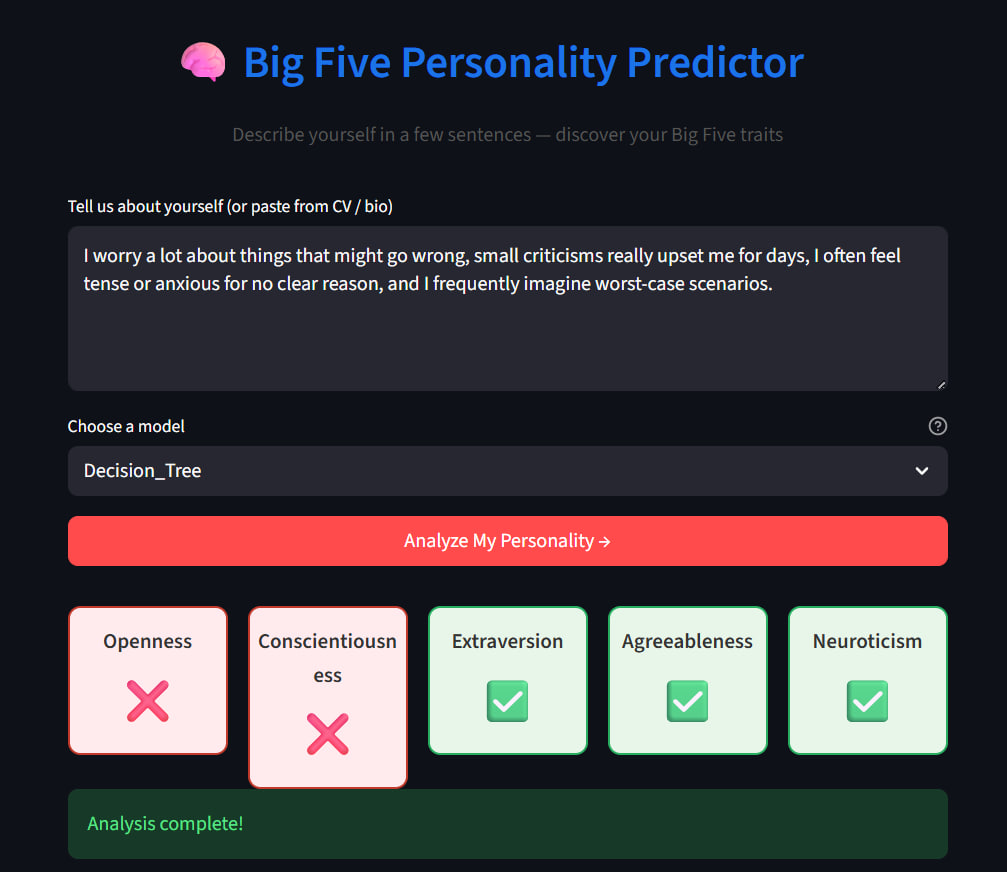

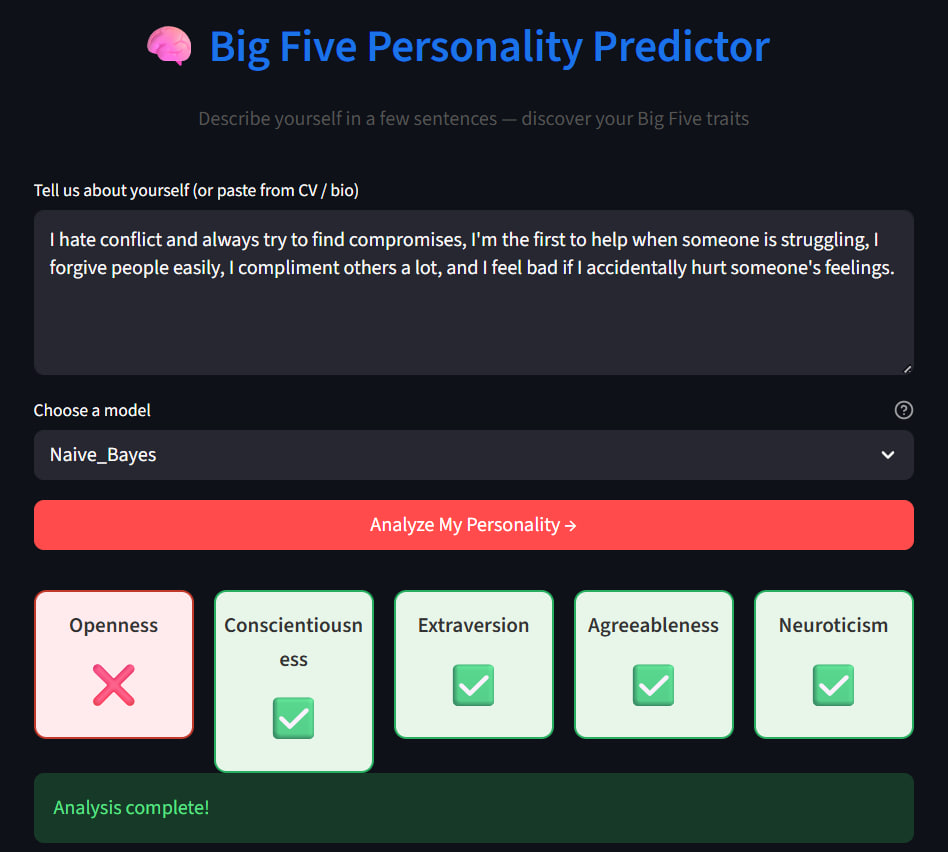